In [1]:
!pip install minisom



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import requests
import zipfile

# Set URL and filename
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"

# Download if not already present
if not os.path.isfile(glove_zip):
    print(f"Downloading {glove_url} ...")
    with requests.get(glove_url, stream=True) as r:
        r.raise_for_status()
        with open(glove_zip, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print("Download completed.")
else:
    print("GloVe zip already downloaded.")

# Unzip
glove_dir = "glove.6B"
if not os.path.exists(glove_dir):
    print("Extracting...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extractall(glove_dir)
    print("Extraction completed.")
else:
    print("GloVe directory already extracted.")

print(f"Files in {glove_dir}:")
print(os.listdir(glove_dir))


GloVe zip already downloaded.
GloVe directory already extracted.
Files in glove.6B:
['glove.6B.200d.txt', 'glove.6B.50d.txt', 'glove.6B.300d.txt', 'glove.6B.100d.txt']


Loaded 400000 words.
Top emotion-related words: ['emotions', 'emotional', 'sadness', 'excitement', 'feelings', 'sense', 'empathy', 'grief', 'anguish', 'feeling', 'expression', 'affection', 'moments', 'tears', 'passion', 'awe', 'perception', 'irony', 'consciousness', 'disgust']


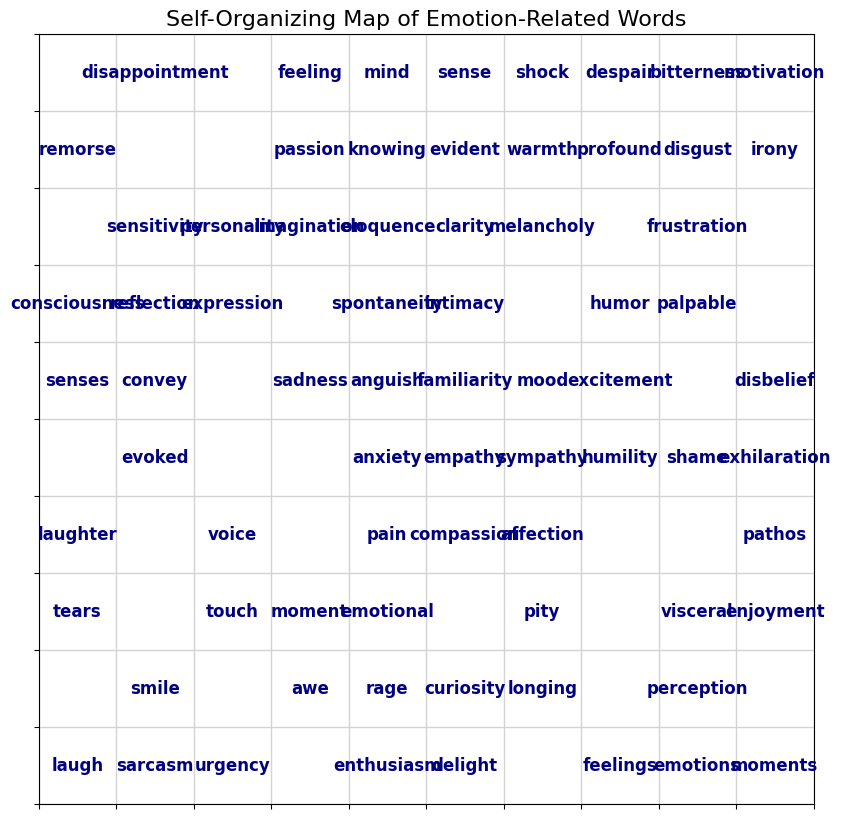

In [4]:
import numpy as np
from minisom import MiniSom
import matplotlib.pyplot as plt

# ---- 1. Load GloVe embeddings ----
GLOVE_PATH = 'glove.6B/glove.6B.100d.txt'

embeddings = {}
with open(GLOVE_PATH, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        embeddings[word] = vector
print(f"Loaded {len(embeddings)} words.")

# ---- 2. Get words with high cosine similarity to "emotion" ----
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

emotion_vec = embeddings['emotion']
similarities = []
for word, vec in embeddings.items():
    if word == 'emotion':
        continue
    sim = cosine_similarity(emotion_vec, vec)
    similarities.append((sim, word))

# Sort and select top N most similar words
similarities.sort(reverse=True)
top_n = 100  # you can try 60-120 for 10x10 grid
emotion_words = [word for sim, word in similarities[:top_n]]
emotion_vectors = np.array([embeddings[word] for word in emotion_words])

print("Top emotion-related words:", emotion_words[:20])

# ---- 3. Train the 10x10 SOM ----
map_size = 10
input_len = emotion_vectors.shape[1]

som = MiniSom(x=map_size, y=map_size, input_len=input_len, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(emotion_vectors)
som.train_random(emotion_vectors, 500)

# ---- 4. Map words to SOM grid ----
word_positions = {}
for i, word in enumerate(emotion_words):
    x, y = som.winner(emotion_vectors[i])
    # Only keep the most similar word for each neuron for a clear plot
    if (x, y) not in word_positions or cosine_similarity(emotion_vec, embeddings[word]) > cosine_similarity(emotion_vec, embeddings[word_positions[(x, y)]]):
        word_positions[(x, y)] = word

# ---- 5. Plotting ----
plt.figure(figsize=(10, 10))
for x in range(map_size):
    for y in range(map_size):
        if (x, y) in word_positions:
            plt.text(x + 0.5, y + 0.5, word_positions[(x, y)], 
                     ha='center', va='center', fontsize=12, color='navy', weight='bold')
        else:
            plt.text(x + 0.5, y + 0.5, '', ha='center', va='center', fontsize=12)
plt.xlim([0, map_size])
plt.ylim([0, map_size])
plt.gca().set_xticks(np.arange(0, map_size+1, 1))
plt.gca().set_yticks(np.arange(0, map_size+1, 1))
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.grid(True, which='both', color='lightgrey', linewidth=1)
plt.gca().invert_yaxis()
plt.title('Self-Organizing Map of Emotion-Related Words', fontsize=16)
plt.show()


Loaded 400000 words.
Found 171 country names in embeddings.


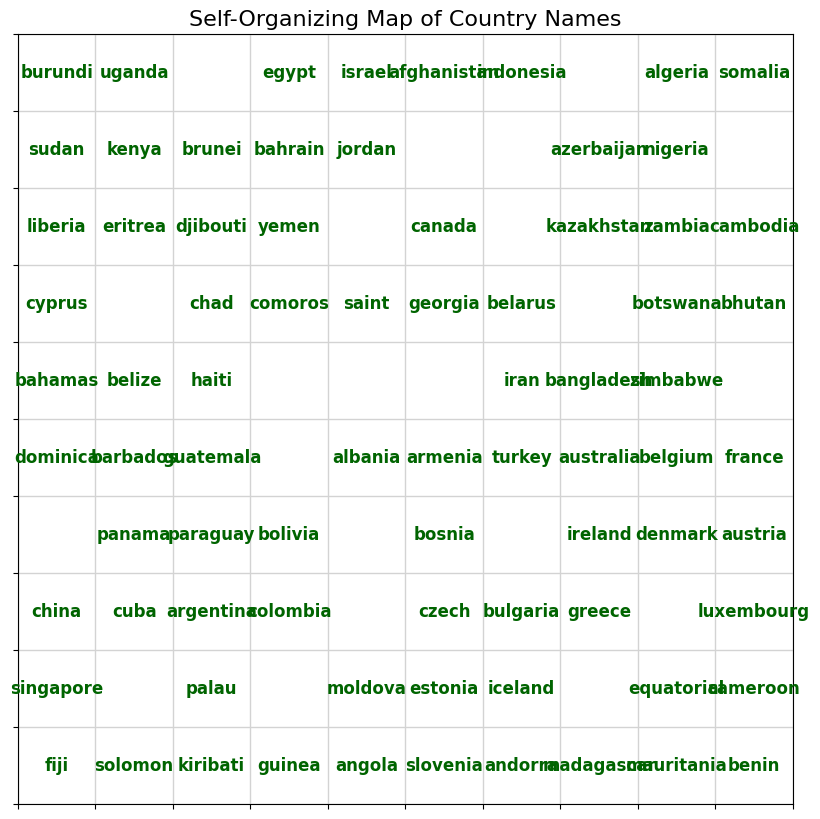

In [5]:
import numpy as np
from minisom import MiniSom
import matplotlib.pyplot as plt

# ---- 1. Load GloVe embeddings ----
GLOVE_PATH = 'glove.6B/glove.6B.100d.txt'

embeddings = {}
with open(GLOVE_PATH, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        embeddings[word] = vector
print(f"Loaded {len(embeddings)} words.")

# ---- 2. List of country names ----
country_list = [
    'afghanistan', 'albania', 'algeria', 'andorra', 'angola', 'argentina', 'armenia', 'australia',
    'austria', 'azerbaijan', 'bahamas', 'bahrain', 'bangladesh', 'barbados', 'belarus', 'belgium',
    'belize', 'benin', 'bhutan', 'bolivia', 'bosnia', 'botswana', 'brazil', 'brunei', 'bulgaria',
    'burkina', 'burundi', 'cambodia', 'cameroon', 'canada', 'chad', 'chile', 'china', 'colombia',
    'comoros', 'congo', 'croatia', 'cuba', 'cyprus', 'czech', 'denmark', 'djibouti', 'dominica',
    'ecuador', 'egypt', 'el_salvador', 'equatorial', 'eritrea', 'estonia', 'ethiopia', 'fiji',
    'finland', 'france', 'gabon', 'gambia', 'georgia', 'germany', 'ghana', 'greece', 'grenada',
    'guatemala', 'guinea', 'guyana', 'haiti', 'honduras', 'hungary', 'iceland', 'india', 'indonesia',
    'iran', 'iraq', 'ireland', 'israel', 'italy', 'jamaica', 'japan', 'jordan', 'kazakhstan',
    'kenya', 'kiribati', 'korea', 'kuwait', 'kyrgyzstan', 'laos', 'latvia', 'lebanon', 'lesotho',
    'liberia', 'libya', 'liechtenstein', 'lithuania', 'luxembourg', 'macedonia', 'madagascar',
    'malawi', 'malaysia', 'maldives', 'mali', 'malta', 'mauritania', 'mauritius', 'mexico',
    'moldova', 'monaco', 'mongolia', 'montenegro', 'morocco', 'mozambique', 'myanmar', 'namibia',
    'nauru', 'nepal', 'netherlands', 'new_zealand', 'nicaragua', 'niger', 'nigeria', 'norway',
    'oman', 'pakistan', 'palau', 'panama', 'papua', 'paraguay', 'peru', 'philippines', 'poland',
    'portugal', 'qatar', 'romania', 'russia', 'rwanda', 'saint', 'samoa', 'san_marino', 'sao_tome',
    'saudi', 'senegal', 'serbia', 'seychelles', 'singapore', 'slovakia', 'slovenia', 'solomon',
    'somalia', 'south_africa', 'spain', 'sri_lanka', 'sudan', 'suriname', 'swaziland', 'sweden',
    'switzerland', 'syria', 'taiwan', 'tajikistan', 'tanzania', 'thailand', 'togo', 'tonga',
    'trinidad', 'tunisia', 'turkey', 'turkmenistan', 'tuvalu', 'uganda', 'ukraine', 'uae',
    'united_kingdom', 'usa', 'uruguay', 'uzbekistan', 'vanuatu', 'venezuela', 'vietnam',
    'yemen', 'zambia', 'zimbabwe'
]

# ---- 3. Filter to those present in GloVe ----
available_countries = [c for c in country_list if c in embeddings]
country_vectors = np.array([embeddings[c] for c in available_countries])
print(f"Found {len(available_countries)} country names in embeddings.")

# ---- 4. SOM training ----
map_size = 10
input_len = country_vectors.shape[1]

som = MiniSom(x=map_size, y=map_size, input_len=input_len, sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(country_vectors)
som.train_random(country_vectors, 1000)

# ---- 5. Map words to SOM grid ----
word_positions = {}
for i, word in enumerate(available_countries):
    x, y = som.winner(country_vectors[i])
    if (x, y) not in word_positions:
        word_positions[(x, y)] = word

# ---- 6. Plotting ----
plt.figure(figsize=(10, 10))
for x in range(map_size):
    for y in range(map_size):
        if (x, y) in word_positions:
            plt.text(x + 0.5, y + 0.5, word_positions[(x, y)],
                     ha='center', va='center', fontsize=12, color='darkgreen', weight='bold')
        else:
            plt.text(x + 0.5, y + 0.5, '', ha='center', va='center', fontsize=12)
plt.xlim([0, map_size])
plt.ylim([0, map_size])
plt.gca().set_xticks(np.arange(0, map_size+1, 1))
plt.gca().set_yticks(np.arange(0, map_size+1, 1))
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.grid(True, which='both', color='lightgrey', linewidth=1)
plt.gca().invert_yaxis()
plt.title('Self-Organizing Map of Country Names', fontsize=16)
plt.show()
